Introduction
============
**Topic**: Setting up a simple 2D environment for testing collisions.

This is an early version of an interactive worksheet regarding "Introduction to path planning".

Version | Author
------------ | -------------
0.3 | Björn Hein

One goal of the notebook series is to discuss and implement algorithms for collision-free path planning. Therefore a concept is needed to represent obstacles and check whether sampled configurations or local connections are valid. This notebook gives a simple implementation of such an environment using the Python library **Shapely**.

License is based on Creative Commons: Attribution-NonCommercial 4.0 International (CC BY-NC 4.0) (pls. check: http://creativecommons.org/licenses/by-nc/4.0/)

Important links are:

* General Info: http://www.python.org
* NetworkX http://networkx.github.io/
* NumPy and SciPy Guide http://docs.scipy.org/
* Matplotlib gallery https://matplotlib.org/stable/
* Shapely https://shapely.readthedocs.io/


# Goal

* Understanding how to set up a simple 2D testing environment
* Understanding how to visualize the environment
* Understanding how to test points and local connections for collision
* Understanding how to wrap these checks in a collision checker for path planning algorithms
* Understanding how to define reusable benchmark scenes with valid start and goal configurations


Set up the Environment
======================

The planning will take place in a certain environment. For testing it is sometimes useful to simplify the environment, e.g. taking a simple 2D approach.

**Remember**: Even if the obstacles are drawn in this notebook, the investigated algorithms must behave as if these **obstacles are not explicitly available**. A planner should only ask whether a configuration or a local connection is valid. This corresponds to an implicit configuration space.


The 2D Python library Shapely is a good choice for this purpose (https://shapely.readthedocs.io/).

Shapely is a BSD-licensed Python package for manipulation and analysis of planar geometric objects. It is based on the widely deployed GEOS library.

Shapely provides much more functionality than needed here. In the context of this lecture, it will mainly be used to test geometric objects for collision.


Idea
-----

The idea is to use the functionality provided by Shapely and define the environment programmatically. Obstacles are stored in a dictionary so that scenes can be passed to a planner or benchmark later.


In [1]:
import matplotlib.pyplot as plt
#%matplotlib notebook

# use following for pdf generation
# %matplotlib inline

from shapely.geometry import Point, Polygon, LineString
from shapely import plotting

Defining a scene
-----------------

1. Definition of obstacles via polygons. 
2. As storage a dict is proposed containing then the "scene"

In [2]:
simpleField = dict()
simpleField["obs1"] = Polygon([(6, 14), (13, 14), (13, 11), (6,11)]).buffer(.02)
simpleField["obs2"] = Polygon([(16, 5), (19, 5), (19, 3),(16,3)]).buffer(1.0)

Based on that scene definition, a simple visualization function can be written:


In [3]:
def drawScene(content, limits=[[0,23],[0,23]], figsize=(10,10), starts=None, goals=None, lines=None):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(1,1,1)
    ax.set_xlim(limits[0])
    ax.set_ylim(limits[1])
    ax.set_aspect("equal")
    ax.grid(True, linewidth=0.3)
    for key, value in content.items():
        plotting.plot_polygon(value, add_points=False, ax=ax, color="red")
    if lines:
        for start, end, color in lines:
            ax.plot([start[0], end[0]], [start[1], end[1]], color=color, linewidth=2)
    if starts:
        ax.scatter([p[0] for p in starts], [p[1] for p in starts], color="green", s=80, label="start")
    if goals:
        ax.scatter([p[0] for p in goals], [p[1] for p in goals], color="orange", s=80, label="goal")
    if starts or goals:
        ax.legend()
    return fig, ax


(<Figure size 300x300 with 1 Axes>, <Axes: >)

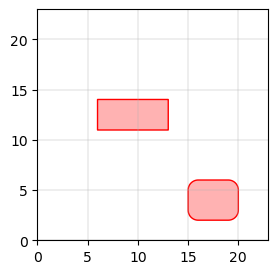

In [4]:
drawScene(simpleField, figsize=(3,3))

In [5]:
trapField = dict()
trapField["obs1"] =   LineString([(6, 18), (6, 8), (16, 8), (16,18)]).buffer(3)

(<Figure size 500x500 with 1 Axes>, <Axes: >)

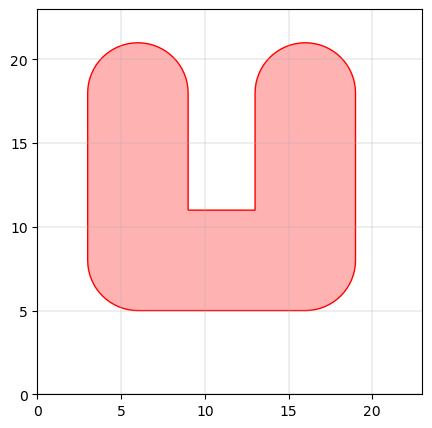

In [6]:
drawScene(trapField, figsize=(5,5))

For a more complicated example see:


In [7]:
special = dict()
special["base"] = LineString([(11,0),(11,18)]).buffer(0.5)
for i in range(15):
    target1 = (11-0.5*i,18-i)
    target2 = (11+0.5*i,18-i)
    special["partA"+str(i)] = LineString([(11,18-i), target1 ]).buffer(0.2)
    special["partB"+str(i)] = LineString([(11,18-i), target2 ]).buffer(0.2)
    if i % 2 == 0:
        special["candA"+str(i)] = LineString([target1, (target1[0], target1[1]+1.5)]).buffer(0.05)
        special["candB"+str(i)] = LineString([target2, (target2[0], target2[1]+1.5)]).buffer(0.05)

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

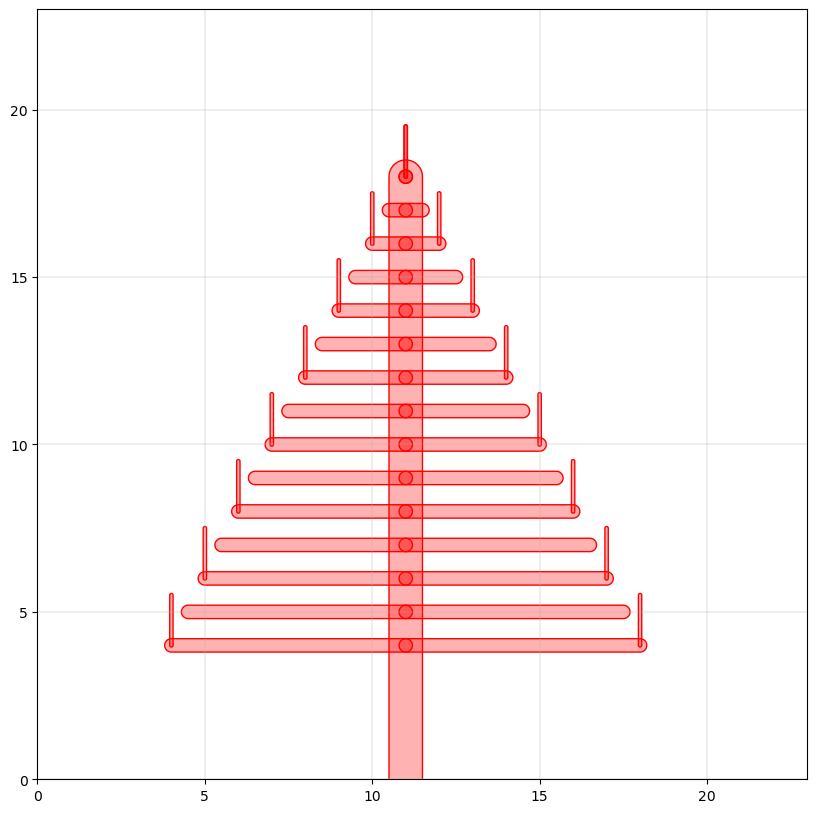

In [8]:
drawScene(special)

Collision checking
=================

One advantage of using shapely is the ability to easily check geometric objects for **intersection** and **distance**.

Point - Point
---------------

In [ ]:
object1 = Point([13,5]).buffer(0.01)
object2 = Point([10,5]).buffer(4.)

print(object1.intersects(object2))
print(object1.distance(object2))

In [ ]:
scene = dict()
scene["ob1"] = object1
scene["ob2"] = object2

In [ ]:
drawScene(scene, figsize=(3,3))

Point-Line example
-----------------------

In [ ]:
lineScene = dict()
lineScene["point"] = Point([10,5]).buffer(1.0).buffer(1.0)
lineScene["ob2"] = LineString([[1,2],[10,10]]).buffer(.1)

print(lineScene["point"].intersects(lineScene["ob2"]))
print(lineScene["point"].distance(lineScene["ob2"]))


In [ ]:
for key, obj in lineScene.items():
    print(key)

In [ ]:
drawScene(lineScene, figsize=(5,5))

Definition of a CollisionChecker
================================

The collision checker hides the obstacle representation from the planner. The planner only needs to ask:

* Is this point/configuration in collision?
* Is the local connection between two configurations in collision?

The same interface is later reused by the planning algorithms through the module `IPEnvironment.py`.


In [ ]:
class CollisionChecker(object):

    def __init__(self, scene, limits=None, statistic=None):
        self.scene = scene
        self.limits = [[0.0, 22.0], [0.0, 22.0]] if limits is None else limits
        self.statistic = statistic
        
    def getDim(self):
        """Return dimension of the environment. Shapely is used here in 2D."""
        return 2
    
    def getEnvironmentLimits(self):
        """Return environment limits."""
        return list(self.limits)

    def isInLimits(self, pos):
        """Return whether a configuration lies inside the configured limits."""
        assert(len(pos) == self.getDim())
        return (self.limits[0][0] <= pos[0] <= self.limits[0][1]
                and self.limits[1][0] <= pos[1] <= self.limits[1][1])

    def pointInCollision(self, pos):
        """Return whether a configuration is invalid.
        Collision or outside limits -> True
        Free and inside limits -> False
        """
        assert(len(pos) == self.getDim())
        if not self.isInLimits(pos):
            return True
        for key, value in self.scene.items():
            if value.intersects(Point(pos[0], pos[1])):              
                return True
        return False

    def lineInCollision(self, startPos, endPos, steps=40):
        """Check a line by sampling intermediate points.
        This is useful to illustrate local planner discretization, but it may miss thin obstacles.
        """
        assert(len(startPos) == self.getDim())
        assert(len(endPos) == self.getDim())
        for i in range(steps + 1):
            t = i / steps
            testPoint = [
                startPos[0] + t * (endPos[0] - startPos[0]),
                startPos[1] + t * (endPos[1] - startPos[1]),
            ]
            if self.pointInCollision(testPoint):
                return True
        return False

    def lineInCollisionExact(self, startPos, endPos):
        """Check whether the exact line segment from startPos to endPos collides."""
        assert(len(startPos) == self.getDim())
        assert(len(endPos) == self.getDim())
        if self.pointInCollision(startPos) or self.pointInCollision(endPos):
            return True
        line = LineString([(startPos[0], startPos[1]), (endPos[0], endPos[1])])
        for key, value in self.scene.items():
            if value.intersects(line):
                return True
        return False
    
    def drawObstacles(self, ax):
        for key, value in self.scene.items():
            plotting.plot_polygon(value, add_points=False, ax=ax, color="red")


Testing and using the collision checker
---------------------------------------

First test single points. The first point lies on an obstacle, the second one is free, and the third one is outside the configured environment limits.


In [ ]:
lineScene = dict()
lineScene["point"] = Point([10,5]).buffer(1.0).buffer(1.0)
lineScene["ob2"] = LineString([[1,2],[10,10]]).buffer(1.0)


In [ ]:
cc = CollisionChecker(lineScene)

As the drawing function is now part of the collision checker, the figure and draw area have to be defined beforehand. Start and goal positions can be drawn on top of the obstacles.


In [ ]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
limits = cc.getEnvironmentLimits()
ax.set_xlim(limits[0])
ax.set_ylim(limits[1])
ax.set_aspect("equal")
ax.grid(True, linewidth=0.3)

cc.drawObstacles(ax)
ax.scatter([2], [5], color="green", s=80, label="free point")
ax.scatter([10], [10], color="orange", s=80, label="collision point")
ax.legend()


In [ ]:
print("[10, 10] in collision:", cc.pointInCollision([10,10]))
print("[2, 5] in collision:", cc.pointInCollision([2,5]))
print("[23, 5] in collision or outside limits:", cc.pointInCollision([23,5]))


In [ ]:
test_lines = [
    ([5, 0], [5, 10], "red"),
    ([5, 0], [10, 0], "green"),
]

for start, end, color in test_lines:
    print(start, "->", end)
    print("  sampled line check:", cc.lineInCollision(start, end))
    print("  exact line check:", cc.lineInCollisionExact(start, end))

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
limits = cc.getEnvironmentLimits()
ax.set_xlim(limits[0])
ax.set_ylim(limits[1])
ax.set_aspect("equal")
ax.grid(True, linewidth=0.3)
cc.drawObstacles(ax)
for start, end, color in test_lines:
    ax.plot([start[0], end[0]], [start[1], end[1]], color=color, linewidth=3)


Benchmark scenes
================

A benchmark combines a scene, a collision checker, one or more start configurations, one or more goal configurations, a short description, and a difficulty level. This makes it easier to compare planners on the same problems.


In [ ]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.append(str(Path.cwd()))
if str(Path.cwd() / "notebooks") not in sys.path:
    sys.path.append(str(Path.cwd() / "notebooks"))

from IPBenchmark import Benchmark
import IPTestSuite as ts


In [ ]:
narrow_passage = dict()
narrow_passage["obs1"] = Polygon([(0, 8), (11, 8), (11, 15), (0, 15)]).buffer(.5)
narrow_passage["obs2"] = Polygon([(13, 8), (24, 8), (24, 15), (13, 15)]).buffer(.5)

description = "Planner has to find a narrow passage with a significant extent."
custom_benchmark = Benchmark(
    "Narrow passage example",
    CollisionChecker(narrow_passage, limits=[[0, 23], [0, 23]]),
    [[4, 21]],
    [[18, 1]],
    description,
    2,
)


In [ ]:
def validateBenchmark(benchmark):
    collisionChecker = benchmark.collisionChecker
    result = True
    for start in benchmark.startList:
        valid = not collisionChecker.pointInCollision(start)
        print("start", start, "valid:", valid)
        result = result and valid
    for goal in benchmark.goalList:
        valid = not collisionChecker.pointInCollision(goal)
        print("goal", goal, "valid:", valid)
        result = result and valid
    return result

def drawBenchmark(benchmark, figsize=(5, 5)):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(1,1,1)
    limits = benchmark.collisionChecker.getEnvironmentLimits()
    ax.set_xlim(limits[0])
    ax.set_ylim(limits[1])
    ax.set_aspect("equal")
    ax.grid(True, linewidth=0.3)
    benchmark.collisionChecker.drawObstacles(ax)
    ax.scatter(
        [p[0] for p in benchmark.startList],
        [p[1] for p in benchmark.startList],
        color="green",
        s=80,
        label="start",
    )
    ax.scatter(
        [p[0] for p in benchmark.goalList],
        [p[1] for p in benchmark.goalList],
        color="orange",
        s=80,
        label="goal",
    )
    ax.set_title(benchmark.name)
    ax.legend()
    return fig, ax


In [ ]:
print(custom_benchmark.description)
print("Benchmark valid:", validateBenchmark(custom_benchmark))
drawBenchmark(custom_benchmark)


Existing test suite
-------------------

The repository contains a small benchmark suite in `IPTestSuite.py`. The loop below visualizes each benchmark and checks whether the provided start and goal configurations are valid.


In [ ]:
for benchmark in ts.benchList:
    print("---", benchmark.name, "---")
    print(benchmark.description)
    print("valid:", validateBenchmark(benchmark))
    drawBenchmark(benchmark)
